# <center>  **<font color='orange'> Nobel Prize Data Story With Visualization  </font>** </center>

### <font color='darkblue'> **Description:** </blue>
<p> This project aims to tell the story of Nobel prizes throughout the years by visualizing patterns in age, gender, nationality, affiliation, and award amount of the Nobel laureates. </p>
<p> Previous regression analysis on the relationship between adjusted prize amount (dependent variable) and year (independent variable) suggests that year could be an indicator of the prize amount but not the only factor that influences it. Therefore, one of the objectives of this notebook is to further analyze the adjusted prize amount to see whether there's a statistically significant correlation between the prize amount and the Nobel prize category. </p>

<p> There are six categories in total: Physics, Chemistry, Physiology or Medicine, Literature, Peace, and Economic Sciences. </p>

## <font color='orange'> Dataset Overview and Statistics Summary </font>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression 
from scipy import stats

In [2]:
df = pd.read_csv('nobel_prize.csv')
df.head()

,awardYear,category,categoryFullName,sortOrder,portion,prizeAmount,prizeAmountAdjusted,dateAwarded,prizeStatus,motivation,...,org_founded_country,org_founded_countryNow,org_founded_locationString,ind_or_org,residence_1,residence_2,affiliation_1,affiliation_2,affiliation_3,affiliation_4
0,2001,Economic Sciences,The Sveriges Riksbank Prize in Economic Scienc...,2,1/3,10000000,12295082,2001-10-10,received,for their analyses of markets with asymmetric ...,...,NaN,NaN,NaN,Individual,NaN,NaN,"Stanford University, Stanford, CA, USA",NaN,NaN,NaN
1,1975,Physics,The Nobel Prize in Physics,1,1/3,630000,3404179,1975-10-17,received,for the discovery of the connection between co...,...,NaN,NaN,NaN,Individual,NaN,NaN,"Niels Bohr Institute, Copenhagen, Denmark",NaN,NaN,NaN
2,2004,Chemistry,The Nobel Prize in Chemistry,1,1/3,10000000,11762861,2004-10-06,received,for the discovery of ubiquitin-mediated protei...,...,NaN,NaN,NaN,Individual,NaN,NaN,"Technion - Israel Institute of Technology, Hai...",NaN,NaN,NaN
3,1982,Chemistry,The Nobel Prize in Chemistry,1,1,1150000,3102518,1982-10-18,received,for his development of crystallographic electr...,...,NaN,NaN,NaN,Individual,NaN,NaN,"MRC Laboratory of Molecular Biology, Cambridge...",NaN,NaN,NaN
4,1979,Physics,The Nobel Prize in Physics,2,1/3,800000,2988048,1979-10-15,received,for their contributions to the theory of the u...,...,NaN,NaN,NaN,Individual,NaN,NaN,"International Centre for Theoretical Physics, ...","Imperial College, London, United Kingdom",NaN,NaN


In [3]:
print(df.shape)
print(df.info())  # can also use df.dtypes

(950, 52)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 52 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   awardYear                   950 non-null    int64 
 1   category                    950 non-null    object
 2   categoryFullName            950 non-null    object
 3   sortOrder                   950 non-null    int64 
 4   portion                     950 non-null    object
 5   prizeAmount                 950 non-null    int64 
 6   prizeAmountAdjusted         950 non-null    int64 
 7   dateAwarded                 533 non-null    object
 8   prizeStatus                 950 non-null    object
 9   motivation                  950 non-null    object
 10  categoryTopMotivation       20 non-null     object
 11  award_link                  950 non-null    object
 12  id                          950 non-null    int64 
 13  name                        950 non-null

In [4]:
print(df.columns)

Index(['awardYear', 'category', 'categoryFullName', 'sortOrder', 'portion',
       'prizeAmount', 'prizeAmountAdjusted', 'dateAwarded', 'prizeStatus',
       'motivation', 'categoryTopMotivation', 'award_link', 'id', 'name',
       'knownName', 'givenName', 'familyName', 'fullName', 'penName', 'gender',
       'laureate_link', 'birth_date', 'birth_city', 'birth_cityNow',
       'birth_continent', 'birth_country', 'birth_countryNow',
       'birth_locationString', 'death_date', 'death_city', 'death_cityNow',
       'death_continent', 'death_country', 'death_countryNow',
       'death_locationString', 'orgName', 'nativeName', 'acronym',
       'org_founded_date', 'org_founded_city', 'org_founded_cityNow',
       'org_founded_continent', 'org_founded_country',
       'org_founded_countryNow', 'org_founded_locationString', 'ind_or_org',
       'residence_1', 'residence_2', 'affiliation_1', 'affiliation_2',
       'affiliation_3', 'affiliation_4'],
      dtype='object')


In [5]:
print(df.describe())

         awardYear   sortOrder   prizeAmount  prizeAmountAdjusted          id
count   950.000000  950.000000  9.500000e+02         9.500000e+02  950.000000
mean   1971.207368    1.483158  3.460596e+06         6.145681e+06  483.043158
std      33.586969    0.688021  4.014530e+06         3.276874e+06  282.644711
min    1901.000000    1.000000  1.149350e+05         2.377268e+06    1.000000
25%    1947.000000    1.000000  1.703320e+05         3.052326e+06  238.250000
50%    1977.000000    1.000000  7.000000e+05         4.997406e+06  477.500000
75%    2000.000000    2.000000  8.000000e+06         9.044276e+06  727.750000
max    2019.000000    3.000000  1.000000e+07         1.229508e+07  984.000000


### <font color='orange'> Check for null values or duplicated rows </font>

In [6]:
df.isnull().sum()

awardYear                       0
category                        0
categoryFullName                0
sortOrder                       0
portion                         0
prizeAmount                     0
prizeAmountAdjusted             0
dateAwarded                   417
prizeStatus                     0
motivation                      0
categoryTopMotivation         930
award_link                      0
id                              0
name                            0
knownName                      27
givenName                      27
familyName                     29
fullName                       27
penName                       939
gender                         27
laureate_link                   0
birth_date                     27
birth_city                     28
birth_cityNow                  28
birth_continent                27
birth_country                  27
birth_countryNow               27
birth_locationString           27
death_date                    320
death_city    

In [7]:
# Extract the row indices of records with an empty value in the birth_date column
null_indices = df[df['birth_date'].isnull()].index
print(len(null_indices))
print(null_indices)

27
Index([ 47,  48, 236, 270, 320, 386, 387, 388, 389, 390, 391, 392, 393, 529,
       590, 615, 617, 634, 639, 677, 697, 875, 876, 877, 944, 948, 949],
      dtype='int64')


In [85]:
for i in null_indices:
    print(data.loc[i, ['name', 'birth_date']])

name          American Friends Service Committee
birth_date                                   NaT
Name: 47, dtype: object
name          Amnesty International
birth_date                      NaT
Name: 48, dtype: object
name          European Union (EU)
birth_date                    NaT
Name: 236, dtype: object
name          Friends Service Council
birth_date                        NaT
Name: 270, dtype: object
name          Grameen Bank
birth_date             NaT
Name: 320, dtype: object
name          Institute of International Law
birth_date                               NaT
Name: 386, dtype: object
name          Intergovernmental Panel on Climate Change
birth_date                                          NaT
Name: 387, dtype: object
name          International Atomic Energy Agency
birth_date                                   NaT
Name: 388, dtype: object
name          International Campaign to Abolish Nuclear Weap...
birth_date                                                  NaT
Name: 

#### <font color='darkblue'> Observation: </color>
<p> All null values in the birth_date column corresponds to an organization. </p>

In [9]:
df.duplicated().sum()

0

### <font color='orange'> General statistics </font>

In [10]:
print("Number of award category:")
for index, value in enumerate(df["category"].unique()):
    print(f'{index+1}: {value}')
print("\n")
    
print(f'Number of awards: {df["category"].value_counts().sum()}\n')
print(f'Number of awards per: {df["category"].value_counts()}\n')

print("Prize share count:")
print(df["portion"].value_counts())

Number of award category:
1: Economic Sciences
2: Physics
3: Chemistry
4: Peace
5: Physiology or Medicine
6: Literature


Number of awards: 950

Number of awards per: category
Physiology or Medicine    219
Physics                   213
Chemistry                 184
Peace                     134
Literature                116
Economic Sciences          84
Name: count, dtype: int64

Prize share count:
portion
1      350
1/2    316
1/3    216
1/4     68
Name: count, dtype: int64


### <font color='darkblue'> Dataset summary: </font>
<p> Dataset of all Nobel prize laureates from 1901 to 2019. </p>
<p> Number of columns: 52 </p>
<p> Number of rows: 950 </p>
<p> There are no duplicated rows but a lot of missing values. Some columns appear to be redundant. </p>

## <font color='orange'> Data Wrangling </font>

### <font color='darkblue'> Step 1: Eliminating unnecessary columns </font>
<p> affiliation_3, affiliation_4, residence_2: These two columns only have one or two not-null values. </p>
<p> knownName, fullName, penName: There are already three other columns for first name, last name, and full name. </p>
<p> birth_cityNow, death_cityNow, residence_1: Not relevant for the project. </p>
<p> birth_locationString, death_locationString: redundant info. </p>
<p> acronym, org_founded_date, org_founded_city, org_founded_cityNow, org_founded_country, org_founded_countryNow, org_founded_locationString: not relevant for the project. </p>

In [11]:
data = df.drop(["affiliation_3", "affiliation_4", "residence_2", "knownName", "fullName", "penName", 
              "birth_cityNow", "death_cityNow", "residence_1", "birth_locationString", "death_locationString", 
              "acronym", "org_founded_date", "org_founded_city", "org_founded_cityNow", "org_founded_country", 
              "org_founded_countryNow", "org_founded_locationString"], axis=1)
data.head()

,awardYear,category,categoryFullName,sortOrder,portion,prizeAmount,prizeAmountAdjusted,dateAwarded,prizeStatus,motivation,...,death_city,death_continent,death_country,death_countryNow,orgName,nativeName,org_founded_continent,ind_or_org,affiliation_1,affiliation_2
0,2001,Economic Sciences,The Sveriges Riksbank Prize in Economic Scienc...,2,1/3,10000000,12295082,2001-10-10,received,for their analyses of markets with asymmetric ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Individual,"Stanford University, Stanford, CA, USA",NaN
1,1975,Physics,The Nobel Prize in Physics,1,1/3,630000,3404179,1975-10-17,received,for the discovery of the connection between co...,...,Copenhagen,Europe,Denmark,Denmark,NaN,NaN,NaN,Individual,"Niels Bohr Institute, Copenhagen, Denmark",NaN
2,2004,Chemistry,The Nobel Prize in Chemistry,1,1/3,10000000,11762861,2004-10-06,received,for the discovery of ubiquitin-mediated protei...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Individual,"Technion - Israel Institute of Technology, Hai...",NaN
3,1982,Chemistry,The Nobel Prize in Chemistry,1,1,1150000,3102518,1982-10-18,received,for his development of crystallographic electr...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Individual,"MRC Laboratory of Molecular Biology, Cambridge...",NaN
4,1979,Physics,The Nobel Prize in Physics,2,1/3,800000,2988048,1979-10-15,received,for their contributions to the theory of the u...,...,Oxford,Europe,United Kingdom,United Kingdom,NaN,NaN,NaN,Individual,"International Centre for Theoretical Physics, ...","Imperial College, London, United Kingdom"


In [12]:
data.to_csv("shortened_nobel_prize.csv", index=False)

### <font color='darkblue'> Step 2: Fixing invalid data </font>

In [13]:
# Example: 

In [14]:
data.loc[0, 'birth_date']  # invalid date

'1943-00-00'

In [15]:
data.loc[0, 'birth_date'] = '1943-11-07'

In [46]:
anhsList

[]

In [47]:
for i in anhsList:
    print(data.loc[i, ['birth_date', 'name']])

In [48]:
data.loc[26, 'birth_date'] = '1898-01-01'  # can't find the actual date of birth 
data.loc[612, 'birth_date'] = '1993-03-10'
data.loc[670, 'birth_date'] = '1955-11-06'
data.loc[785, 'birth_date'] = '1959-09-22'
data.loc[880, 'birth_date'] = '1952-01-01'  # can't find the actual date of birth 

In [49]:
data.to_csv('nobel_prize_with_valid_birth_date.csv', index=False)

## <font color='salmon'> Plot the distribution of adjusted prize amount over the years </font>

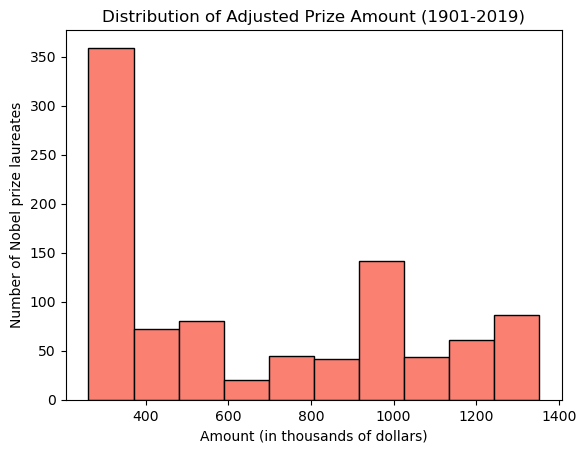

In [20]:
amount_in_thousands = (data["prizeAmountAdjusted"].to_numpy() * 0.11) / 1000  # 1 SEK = 0.11 USD 

plt.hist(amount_in_thousands, color="salmon", edgecolor="black")

# Adding title and axis labels 
plt.title("Distribution of Adjusted Prize Amount (1901-2019)")
plt.xlabel("Amount (in thousands of dollars)")
plt.ylabel("Number of Nobel prize laureates");

## <font color='salmon'> Plot the distribution of adjusted prize amount in each award category </font>

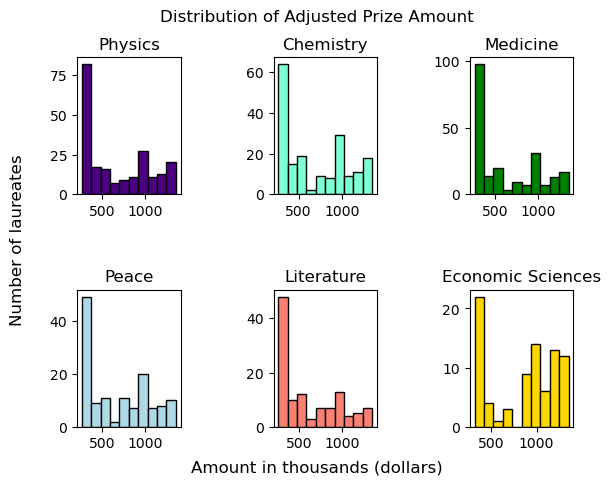

In [21]:
fig = plt.figure()

# First chart: Physics 
ax1 = fig.add_subplot(2,3,1)
physics = data[data["category"] == "Physics"]
amount_in_thousands = (physics["prizeAmountAdjusted"].to_numpy() * 0.11) / 1000 
ax1.hist(amount_in_thousands, color="indigo", edgecolor="black")
ax1.set_title("Physics"); 

# Second chart: Chemistry 
ax2 = fig.add_subplot(2,3,2)
chemistry = data[data["category"] == "Chemistry"]
amount_in_thousands = (chemistry["prizeAmountAdjusted"].to_numpy() * 0.11) / 1000 
ax2.hist(amount_in_thousands, color="aquamarine", edgecolor="black")
ax2.set_title("Chemistry"); 

# Third chart: Physiology or Medicine
ax3 = fig.add_subplot(2,3,3)
physiology = data[data["category"] == "Physiology or Medicine"]
amount_in_thousands = (physiology["prizeAmountAdjusted"].to_numpy() * 0.11) / 1000 
ax3.hist(amount_in_thousands, color="green", edgecolor="black")
ax3.set_title("Medicine"); 

# Fourth chart: Peace
ax4 = fig.add_subplot(2,3,4)
peace = data[data["category"] == "Peace"]
amount_in_thousands = (peace["prizeAmountAdjusted"].to_numpy() * 0.11) / 1000 
ax4.hist(amount_in_thousands, color="lightblue", edgecolor="black")
ax4.set_title("Peace"); 

# Fifth chart: Literature
ax5 = fig.add_subplot(2,3,5)
literature = data[data["category"] == "Literature"]
amount_in_thousands = (literature["prizeAmountAdjusted"].to_numpy() * 0.11) / 1000 
ax5.hist(amount_in_thousands, color="salmon", edgecolor="black")
ax5.set_title("Literature"); 

# Fifth chart: Economic Sciences
ax6 = fig.add_subplot(2,3,6)
economic = data[data["category"] == "Economic Sciences"]
amount_in_thousands = (economic["prizeAmountAdjusted"].to_numpy() * 0.11) / 1000 
ax6.hist(amount_in_thousands, color="gold", edgecolor="black")
ax6.set_title("Economic Sciences"); 


plt.subplots_adjust(wspace=0.9, hspace=0.7)
fig.suptitle("Distribution of Adjusted Prize Amount")
fig.supxlabel("Amount in thousands (dollars)")
fig.supylabel("Number of laureates"); 

<p> Observation: The distribution of adjusted prize amount varies from category to category.  </p>

## <font color='orange'> Statistical Testing </color>

### <font color='darkblue'> Kendall's Tau correlation </color>

<p> Kendall's Tau correlation measures the strength between two variables. This is a more suitable choice compared to Pearson correlation as the Pearson correlation requires both variables to be continuous, have a linear relationship, and is normally distributed. The Kendall's Tau correlation does not assume any of this. In addition, it is more robust than the Spearman rank correlation if the dataset is smaller.</p>

In [22]:
tau, p_value = stats.kendalltau(data["awardYear"], data["prizeAmountAdjusted"])
print(f"Kendall's Tau correlation coefficient: {tau}")
print(f"p-value: {p_value}")

Kendall's Tau correlation coefficient: 0.40450727396277597
p-value: 2.0296085149325e-76


#### <font color='darkblue'> Interpretation: </color>
<p> Positive correlation indicates that as one variable increases, the other tends to increase. Since the correlation value is between 0.26 and 0.49, the magnitude of the Kendall's Tau correlation is considered to be moderate based on the recommendations established by <a href=https://journals.lww.com/anesthesia-analgesia/Fulltext/2018/05000/Correlation_Coefficients__Appropriate_Use_and.50.aspx> Schober, Boer, and Schwarte (2018) </a>. </p>

In [23]:
print("Physics:")
tau, p_value_1 = stats.kendalltau(physics["awardYear"], physics["prizeAmountAdjusted"])
print(f"Kendall's Tau correlation coefficient: {tau}")
print(f"p-value: {p_value_1}\n")

print("Chemistry:")
tau, p_value_2 = stats.kendalltau(chemistry["awardYear"], chemistry["prizeAmountAdjusted"])
print(f"Kendall's Tau correlation coefficient: {tau}")
print(f"p-value: {p_value_2}\n")

print("Physiology or Medicine:")
tau, p_value_3 = stats.kendalltau(physiology["awardYear"], physiology["prizeAmountAdjusted"])
print(f"Kendall's Tau correlation coefficient: {tau}")
print(f"p-value: {p_value_3}\n")

print("Peace:")
tau, p_value_4 = stats.kendalltau(peace["awardYear"], peace["prizeAmountAdjusted"])
print(f"Kendall's Tau correlation coefficient: {tau}")
print(f"p-value: {p_value_4}\n")

print("Literature:")
tau, p_value_5 = stats.kendalltau(literature["awardYear"], literature["prizeAmountAdjusted"])
print(f"Kendall's Tau correlation coefficient: {tau}")
print(f"p-value: {p_value_5}\n")

print("Economic Sciences:")
tau, p_value_6 = stats.kendalltau(economic["awardYear"], economic["prizeAmountAdjusted"])
print(f"Kendall's Tau correlation coefficient: {tau}")
print(f"p-value: {p_value_6}\n")

Physics:
Kendall's Tau correlation coefficient: 0.4083606424342752
p-value: 1.2137104132826377e-18

Chemistry:
Kendall's Tau correlation coefficient: 0.39968925468108557
p-value: 1.1663059230532009e-15

Physiology or Medicine:
Kendall's Tau correlation coefficient: 0.4078414897787494
p-value: 4.417292802022051e-19

Peace:
Kendall's Tau correlation coefficient: 0.32720921618180837
p-value: 2.342555320475415e-08

Literature:
Kendall's Tau correlation coefficient: 0.23975994268364478
p-value: 0.0001372584352108701

Economic Sciences:
Kendall's Tau correlation coefficient: 0.4281151784915829
p-value: 1.2088143555340668e-08



#### <font color='darkblue'> Interpretation: </color>
<p> Award year and adjusted prize amount have the strongest relationship in the Economic Sciences category and the weakest relationship in the Literature category. </p>
<p> Ranking: Economic Sciences, Physics, Physiology or Medicine, Chemistry, Peace, and Literature.</p>

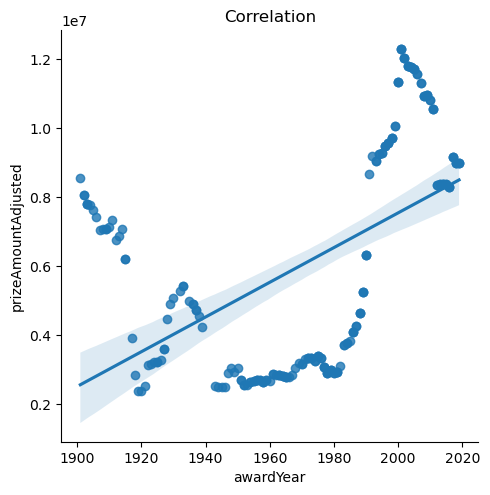

In [24]:
sns.lmplot(x="awardYear", y="prizeAmountAdjusted", data=physics)
plt.title("Correlation")
plt.show()

## <font color='orange'> K-means Clustering Algorithm </font>

In [25]:
data["portion"].unique()

array(['1/3', '1', '1/4', '1/2'], dtype=object)

### <font color='darkblue'> Create a scatter plot </font>

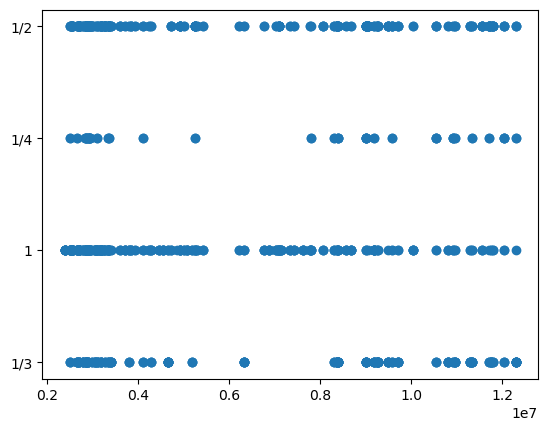

In [26]:
plt.scatter(data["prizeAmountAdjusted"], data["portion"])

In [27]:
def parse_fraction(val):
    try:
        if '/' in str(val):
            return float(eval(val)) 
        else:
            return float(val)
    except:
        return np.nan 

In [28]:
data_k = data[["prizeAmountAdjusted", "portion"]]
data_k["portion"] = data_k["portion"].apply(parse_fraction)
data_k

C:\Users\nguye\AppData\Local\Temp\ipykernel_27184\1969625224.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_k["portion"] = data_k["portion"].apply(parse_fraction)


,prizeAmountAdjusted,portion
0,12295082,0.333333
1,3404179,0.333333
2,11762861,0.333333
3,3102518,1.000000
4,2988048,0.333333
...,...,...
945,3345725,0.333333
946,2640218,1.000000
947,7327865,1.000000
948,2929688,1.000000


In [29]:
k = 2
centers = [(12295082, 0.33), (3102518, 1)]

In [30]:
# Loop for each center and calculate Euclidean distance of each row 
dist = np.empty((data_k.shape[0], k))
for i in range(k):
    dist[:,i] = np.sum((data_k - centers[i])**2, axis=1)
    
print(dist)

[[1.11111111e-05 8.45032329e+13]
 [7.90481562e+13 9.09993589e+10]
 [2.83259193e+11 7.50015409e+13]
 ...
 [2.46732447e+13 1.78535573e+13]
 [8.77106048e+13 2.98702089e+10]
 [8.94120780e+13 6.92910858e+10]]


In [31]:
# Find the cluster index with the smallest distance with argmin and add as new column 
data_k["cluster"] = np.argmin(dist, axis=1)
data_k

C:\Users\nguye\AppData\Local\Temp\ipykernel_27184\2448429493.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_k["cluster"] = np.argmin(dist, axis=1)


,prizeAmountAdjusted,portion,cluster
0,12295082,0.333333,0
1,3404179,0.333333,1
2,11762861,0.333333,0
3,3102518,1.000000,1
4,2988048,0.333333,1
...,...,...,...
945,3345725,0.333333,1
946,2640218,1.000000,1
947,7327865,1.000000,1
948,2929688,1.000000,1


In [32]:
# Determine new centers 
centers = data_k.groupby("cluster").mean()
centers

,prizeAmountAdjusted,portion
cluster,,
0,9.916578e+06,0.534435
1,3.813763e+06,0.686542


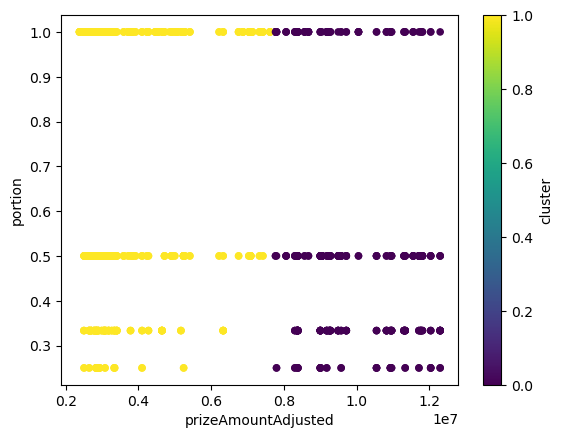

In [33]:
data_k.plot.scatter(x='prizeAmountAdjusted', y='portion', c='cluster', cmap='viridis');

In [35]:
# convergence check, if you get a new cluster membership, subtract and sum absolute differences
np.sum(np.abs(data_k["cluster"] - data_k["cluster"]))

0

#### <font color='darkblue'> Interpretation: </color>
<p> The clusters aren't very obvious, which suggests a lack of strong correlation between the two variables portion and prizeAmountAdjusted.</p>

## <font color='orange'> More Data Wrangling </font>

### <font color='darkblue'> Step 1: Determine rows with an invalid birth_date </font>

In [36]:
# Convert the birth_date column into DateTime objects

data['birth_date'] = pd.to_datetime(data['birth_date'],format='%Y-%m-%d', errors='coerce')

In [37]:
list = data['birth_date'].isnull()
list

0      False
1      False
2      False
3      False
4      False
       ...  
945    False
946    False
947    False
948     True
949     True
Name: birth_date, Length: 950, dtype: bool

In [38]:
indices = [i for i, val in enumerate(list) if val]
print(len(indices))
print(indices)

27
[47, 48, 236, 270, 320, 386, 387, 388, 389, 390, 391, 392, 393, 529, 590, 615, 617, 634, 639, 677, 697, 875, 876, 877, 944, 948, 949]


In [39]:
# This means there are six invalid values in the birth_date column, as the initial number of null values is 27.
anhsList = []
for i, val in enumerate(indices):
    if not val in null_indices:
        print(val)
        anhsList.append(val)
        
print(anhsList)

[]


### <font color='darkblue'> Step 3: Add an age column </font>

In [40]:
data['age'] = data['awardYear'] - data['birth_date'].dt.year

In [41]:
data['age']

0      58.0
1      53.0
2      57.0
3      56.0
4      53.0
       ... 
945    64.0
946    53.0
947    44.0
948     NaN
949     NaN
Name: age, Length: 950, dtype: float64

In [42]:
data.head()

,awardYear,category,categoryFullName,sortOrder,portion,prizeAmount,prizeAmountAdjusted,dateAwarded,prizeStatus,motivation,...,death_continent,death_country,death_countryNow,orgName,nativeName,org_founded_continent,ind_or_org,affiliation_1,affiliation_2,age
0,2001,Economic Sciences,The Sveriges Riksbank Prize in Economic Scienc...,2,1/3,10000000,12295082,2001-10-10,received,for their analyses of markets with asymmetric ...,...,NaN,NaN,NaN,NaN,NaN,NaN,Individual,"Stanford University, Stanford, CA, USA",NaN,58.0
1,1975,Physics,The Nobel Prize in Physics,1,1/3,630000,3404179,1975-10-17,received,for the discovery of the connection between co...,...,Europe,Denmark,Denmark,NaN,NaN,NaN,Individual,"Niels Bohr Institute, Copenhagen, Denmark",NaN,53.0
2,2004,Chemistry,The Nobel Prize in Chemistry,1,1/3,10000000,11762861,2004-10-06,received,for the discovery of ubiquitin-mediated protei...,...,NaN,NaN,NaN,NaN,NaN,NaN,Individual,"Technion - Israel Institute of Technology, Hai...",NaN,57.0
3,1982,Chemistry,The Nobel Prize in Chemistry,1,1,1150000,3102518,1982-10-18,received,for his development of crystallographic electr...,...,NaN,NaN,NaN,NaN,NaN,NaN,Individual,"MRC Laboratory of Molecular Biology, Cambridge...",NaN,56.0
4,1979,Physics,The Nobel Prize in Physics,2,1/3,800000,2988048,1979-10-15,received,for their contributions to the theory of the u...,...,Europe,United Kingdom,United Kingdom,NaN,NaN,NaN,Individual,"International Centre for Theoretical Physics, ...","Imperial College, London, United Kingdom",53.0


### <font color='darkblue'> Step 4: Create a dataset with only individual Nobel laureates </font>

In [43]:
data_individual = data.dropna(subset=['birth_date'])

In [44]:
data_individual.isnull().sum()

awardYear                  0
category                   0
categoryFullName           0
sortOrder                  0
portion                    0
prizeAmount                0
prizeAmountAdjusted        0
dateAwarded              417
prizeStatus                0
motivation                 0
categoryTopMotivation    903
award_link                 0
id                         0
name                       0
givenName                  0
familyName                 2
gender                     0
laureate_link              0
birth_date                 0
birth_city                 1
birth_continent            0
birth_country              0
birth_countryNow           0
death_date               293
death_city               312
death_continent          306
death_country            306
death_countryNow         306
orgName                  923
nativeName               923
org_founded_continent    923
ind_or_org                 0
affiliation_1            226
affiliation_2            856
age           

In [45]:
data_individual.to_csv('individual_nobel_prize.csv', index=False)

## <font color='orange'> Classification </font>

### <font color='darkblue'> Step 1: Select the columns </font>

In [50]:
data_classification = data_individual[['age', 'prizeAmountAdjusted', 'category']]
data_classification

# Category is the label column; age and prizeAmountAdjusted are the attributes 

,age,prizeAmountAdjusted,category
0,58.0,12295082,Economic Sciences
1,53.0,3404179,Physics
2,57.0,11762861,Chemistry
3,56.0,3102518,Chemistry
4,53.0,2988048,Physics
...,...,...,...
942,70.0,11333109,Physics
943,62.0,2889667,Chemistry
945,64.0,3345725,Physics
946,53.0,2640218,Chemistry


### <font color='darkblue'> Step 2: Normalize the numerical values using min-max normalization </font>

In [51]:
data_norm = data_classification.copy()
for col in data_norm.columns:
    if data_norm[col].dtype != 'object':
        min_value = data_norm[col].min()
        max_value = data_norm[col].max()
        data_norm[col] = (data_norm[col] - min_value) / (max_value - min_value)

In [52]:
data_norm

,age,prizeAmountAdjusted,category
0,0.5125,1.000000,Economic Sciences
1,0.4500,0.103542,Physics
2,0.5000,0.946337,Chemistry
3,0.4875,0.073126,Chemistry
4,0.4500,0.061584,Physics
...,...,...,...
942,0.6625,0.903006,Physics
943,0.5625,0.051665,Chemistry
945,0.5875,0.097648,Physics
946,0.4500,0.026513,Chemistry


### <font color='darkblue'> Step 3: Split the dataset into training (70%) and testing (30%) sets </font>

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
X = data_norm[['age', 'prizeAmountAdjusted']]
y = data_norm['category']

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=4220)

In [56]:
train_size = int(len(data_norm) * 0.7)
training_set = data_norm[:train_size]
testing_set = data_norm[train_size:]

### <font color='darkblue'> Step 4: Create a kNN model from Scratch </font>

In [57]:
def euclidean_distance(x1, x2):
    distance = np.sqrt(np.sum((x1 - x2)**2))
    return distance 

In [58]:
from collections import Counter

In [59]:
class KNN:
    def __init__(self, k=3):
        self.k = k
        
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        
    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return predictions 
    
    def _predict(self, x):
        # compute the Euclidean distance between x and all other data points 
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]
        
        # get the closest k 
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train.iloc[i] for i in k_indices]
        
        # majority vote
        most_common = Counter(k_nearest_labels).most_common()
        return most_common[0][0]

In [60]:
clf = KNN(k=5)
clf.fit(training_set['age'], training_set['category'])
predictions = clf.predict(testing_set['age'])

In [61]:
print(predictions)

['Chemistry', 'Physics', 'Chemistry', 'Physiology or Medicine', 'Chemistry', 'Economic Sciences', 'Chemistry', 'Physiology or Medicine', 'Peace', 'Chemistry', 'Physiology or Medicine', 'Chemistry', 'Physiology or Medicine', 'Chemistry', 'Literature', 'Chemistry', 'Literature', 'Physiology or Medicine', 'Physics', 'Physiology or Medicine', 'Peace', 'Peace', 'Physiology or Medicine', 'Chemistry', 'Chemistry', 'Physics', 'Physiology or Medicine', 'Chemistry', 'Literature', 'Physics', 'Chemistry', 'Physics', 'Chemistry', 'Literature', 'Economic Sciences', 'Physics', 'Physiology or Medicine', 'Literature', 'Literature', 'Chemistry', 'Peace', 'Chemistry', 'Economic Sciences', 'Physics', 'Physics', 'Peace', 'Physiology or Medicine', 'Economic Sciences', 'Chemistry', 'Chemistry', 'Chemistry', 'Physics', 'Physiology or Medicine', 'Physiology or Medicine', 'Physiology or Medicine', 'Peace', 'Physics', 'Physics', 'Physics', 'Physics', 'Physics', 'Physiology or Medicine', 'Chemistry', 'Chemistry',

### <font color='darkblue'> Step 5: Report the success of the kNN implementation </font>

#### <font color='red'> Accuracy </font>

In [62]:
acc = np.sum(predictions == y_test) / len(y_test)
print(acc)

0.17689530685920576


In [63]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [64]:
y_true = y_test
y_pred = predictions

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[17  5 12  3 14 14]
 [ 8  3  4  3  3  4]
 [12  4  5  0 11  7]
 [ 6  2  2  0  6 10]
 [15  4  5  4 10 19]
 [15  7 10  4 15 14]]


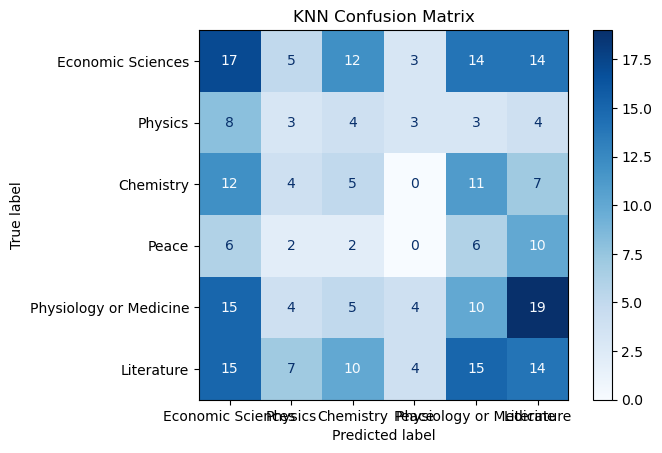

In [65]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = data_norm['category'].unique())
disp.plot(cmap=plt.cm.Blues)
plt.title("KNN Confusion Matrix")
plt.show()

#### <font color='red'> Recall (True Positive Rate) </font>

In [66]:
# Economic Sciences
recall_econ = 17 / (17 + (5 + 12 + 3 + 14 + 14))
print(f"Recall for Economic Sciences: {recall_econ}")

# Physics
recall_physics = 3 / (3 + (8 + 4 + 3 + 3 + 4))
print(f"Recall for Physics: {recall_physics}")

# Chemistry
recall_chemistry = 5 / (5 + (4 + 5 + 0 + 11 + 7))
print(f"Recall for Chemistry: {recall_chemistry}")

# Peace
recall_peace = 0 / (0 + (2 + 2 + 6 + 6 + 10))
print(f"Recall for Peace: {recall_peace}")

# Physiology or Medicine 
recall_medicine = 10 / (10 + (4 + 5 + 4 + 15 + 19))
print(f"Recall for Medicine: {recall_medicine}")

# Literature 
recall_literature = 15 / (15 + (7 + 10 + 4 + 15 + 14))
print(f"Recall for Literature: {recall_literature}")

Recall for Economic Sciences: 0.26153846153846155
Recall for Physics: 0.12
Recall for Chemistry: 0.15625
Recall for Peace: 0.0
Recall for Medicine: 0.17543859649122806
Recall for Literature: 0.23076923076923078


#### <font color='red'> Precision </font>

In [67]:
prec_econ = 17 / (17 + (8 + 12 + 6 + 15 + 15))
print(f"Precision for Economic Sciences: {prec_econ}")

# Physics
prec_physics = 3 / (3 + (5 + 4 + 2 + 4 +7))
print(f"Precision for Physics: {prec_physics}")

# Chemistry
prec_chemistry = 5 / (5 + (12 + 4 + 2 + 5 + 10))
print(f"Precision for Chemistry: {prec_chemistry}")

# Peace
prec_peace = 0 / (0 + (3 + 3 + 0 + 4 + 4))
print(f"Recall for Peace: {prec_peace}")

# Physiology or Medicine 
prec_medicine = 10 / (10 + (14 + 3 + 11 + 6 + 15))
print(f"Recall for Medicine: {prec_medicine}")

# Literature 
prec_literature = 14 / (14 + (14 + 4 + 7 + 10 + 19))
print(f"Recall for Literature: {prec_literature}")

Precision for Economic Sciences: 0.2328767123287671
Precision for Physics: 0.12
Precision for Chemistry: 0.13157894736842105
Recall for Peace: 0.0
Recall for Medicine: 0.1694915254237288
Recall for Literature: 0.20588235294117646


#### <font color='red'> False Negative Rate </font>

In [68]:
fnr_econ = (8 + 12 + 6 + 15 + 15) / (8 + 12 + 6 + 15 + 15 + 17)
print(f"False negative rate for Economic Sciences: {fnr_econ}")

# Physics
fnr_physics = (5 + 4 + 2 + 4 + 7) / (5 + 4 + 2 + 4 + 7 + 3)
print(f"False negative rate for Physics: {fnr_physics}")

# Chemistry
fnr_chemistry = (12 + 4 + 2 + 5 + 10) / (12 + 4 + 2 + 5 + 10 + 5)
print(f"False negative rate for Chemistry: {fnr_chemistry}")

# Peace
fnr_peace = (3 + 3 + 0 + 4 + 4) / (3 + 3 + 0 + 4 + 4 + 0)
print(f"False negative rate for Peace: {fnr_peace}")

# Physiology or Medicine 
fnr_medicine = (14 + 3 + 11 + 6 + 15) / (14 + 3 + 11 + 6 + 15 + 10)
print(f"False negative rate for Medicine: {fnr_medicine}")

# Literature 
fnr_literature = (14 + 4 + 7 + 10 + 19) / (14 + 4 + 7 + 10 + 19 + 14)
print(f"False negative rate for Literature: {fnr_literature}")

False negative rate for Economic Sciences: 0.7671232876712328
False negative rate for Physics: 0.88
False negative rate for Chemistry: 0.868421052631579
False negative rate for Peace: 1.0
False negative rate for Medicine: 0.8305084745762712
False negative rate for Literature: 0.7941176470588235


## <font color='orange'> Dimensionality Reduction with PCA </font>

In [69]:
data_PCA = data_individual[['age', 'prizeAmountAdjusted', 'prizeAmount']]
data_PCA.head()

,age,prizeAmountAdjusted,prizeAmount
0,58.0,12295082,10000000
1,53.0,3404179,630000
2,57.0,11762861,10000000
3,56.0,3102518,1150000
4,53.0,2988048,800000


### <font color='darkblue'> Step 1: Find the covariance matrix </font>

In [70]:
X = (data_PCA - data_PCA.mean()) / data_PCA.std(ddof=1)
n = X.shape[0]
cov_1 = (X.T @ X) / (n - 1)
print(cov_1)

                          age  prizeAmountAdjusted  prizeAmount
age                  1.000000             0.269637     0.332563
prizeAmountAdjusted  0.269637             1.000000     0.899137
prizeAmount          0.332563             0.899137     1.000000


In [71]:
cov_2 = np.cov(data_PCA.T)
print(cov_2)

[[1.58032771e+02 1.10948988e+07 1.67699902e+07]
 [1.10948988e+07 1.07137252e+13 1.18054312e+13]
 [1.67699902e+07 1.18054312e+13 1.60905765e+13]]


### <font color='darkblue'> Step 2: Find the eigenvalues and eigenvectors of the covariance matrix </font>

In [72]:
eig_vals, eig_vecs = np.linalg.eig(cov_2)

print("Eigenvalues:\n", eig_vals)
print("Eigenvectors:\n", eig_vecs)


# Sort eigenvalues
idx = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[idx]
eig_vecs = eig_vecs[:, idx]

print("Sorted eigenvalues:\n", eig_vals)
print("Sorted eigenvectors:\n", eig_vecs)

Eigenvalues:
 [1.39843750e+02 2.55098277e+13 1.29447405e+12]
Eigenvectors:
 [[ 1.00000000e+00 -7.85125857e-07  1.38008568e-06]
 [ 5.89115144e-07 -6.23681384e-01 -7.81678663e-01]
 [-1.47444987e-06 -7.81678663e-01  6.23681384e-01]]
Sorted eigenvalues:
 [2.55098277e+13 1.29447405e+12 1.39843750e+02]
Sorted eigenvectors:
 [[-7.85125857e-07  1.38008568e-06  1.00000000e+00]
 [-6.23681384e-01 -7.81678663e-01  5.89115144e-07]
 [-7.81678663e-01  6.23681384e-01 -1.47444987e-06]]


In [73]:
from sklearn.decomposition import PCA

In [74]:
pca = PCA()
pca.fit(X)

print(pca.components_)
print("\n")
print(pca.explained_variance_)

[[ 0.37036604  0.6508739   0.66271575]
 [ 0.92722847 -0.30165501 -0.22192707]
 [-0.05546498 -0.69668316  0.71523158]]


[2.06892679 0.83268201 0.0983912 ]


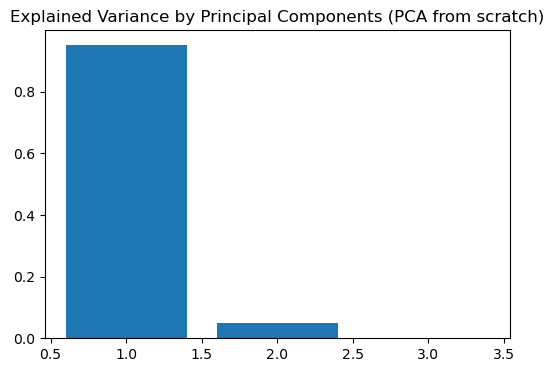

In [75]:
plt.figure(figsize=(6,4))
plt.bar(range(1, len(eig_vals)+1), eig_vals / np.sum(eig_vals))
plt.title('Explained Variance by Principal Components (PCA from scratch)')
plt.show()

In [76]:
# PCA can reduce the number of dimensions because in this case, the first component explains the majority of the data already.

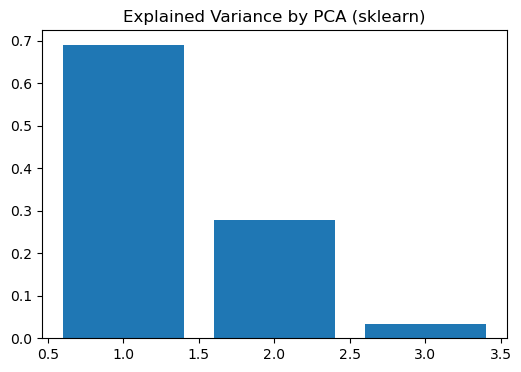

In [77]:
plt.figure(figsize=(6,4))
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_)
plt.title('Explained Variance by PCA (sklearn)')
plt.show()

### <font color='darkblue'> Step 4: Transform the dataset onto the PC bases </font>

In [78]:
transformed_pca = pca.transform(X)
print("Transformed data:\n", transformed_pca)

Transformed data:
 [[ 2.25235231e+00 -1.06410260e+00 -1.33857179e-01]
 [-1.21095236e+00 -9.51156299e-02  1.09886883e-01]
 [ 2.11705824e+00 -1.08881205e+00 -1.61640819e-02]
 ...
 [-9.23279229e-01  7.29915834e-01  4.70498860e-02]
 [-1.43693964e+00  9.59667903e-05  1.92549668e-01]
 [-7.76719792e-01 -1.09347791e+00 -7.72789253e-01]]


C:\Users\nguye\anaconda3\Lib\site-packages\matplotlib\collections.py:996: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


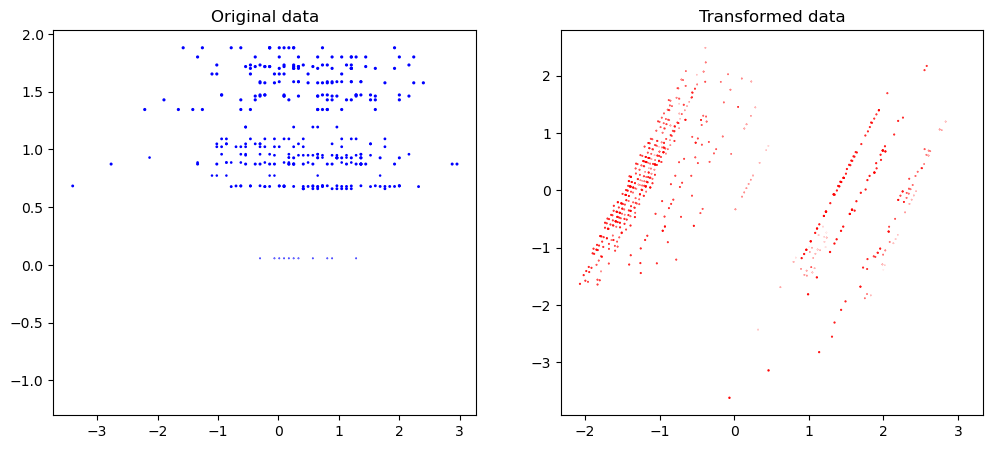

In [79]:
plt.figure(figsize=(12,5))

# Original feature space
plt.subplot(1, 2, 1)
plt.scatter(X['age'], X['prizeAmountAdjusted'], X['prizeAmount'], color='blue')
plt.title("Original data")

# Transformed feature space 
plt.subplot(1, 2, 2)
plt.scatter(transformed_pca[:,0], transformed_pca[:,1], transformed_pca[:,2], color='red')
plt.title("Transformed data")

plt.show()

<p> Observation: The way the data points cluster diagonally in the second plot demonstrates that the PCA works as the PCA algorithm finds a different axis that best captures most of the variance in the data. </p>

In [80]:
data_individual['age'].describe()

count    923.000000
mean      59.823402
std       12.571109
min       17.000000
25%       51.000000
50%       60.000000
75%       69.000000
max       97.000000
Name: age, dtype: float64

In [81]:
mean_age = data_individual['age'].mean()
print(mean_age)

59.82340195016251


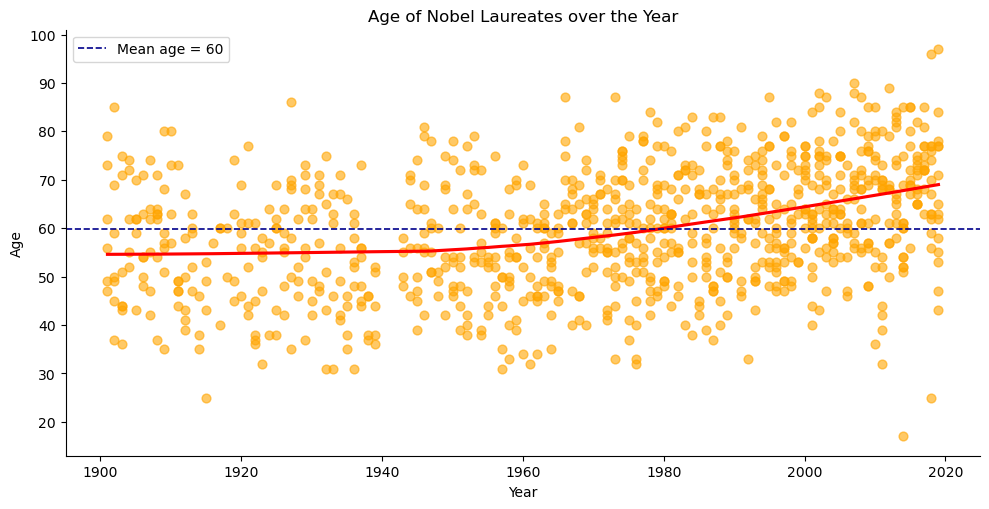

In [82]:
sns.lmplot(x='awardYear' ,y='age' ,data=data_individual, lowess=True , aspect=2 ,line_kws={'color' : 'red'}, scatter_kws={'color': 'orange', 'alpha': 0.6, 's': 40} )

plt.axhline(mean_age, color='darkblue', linestyle='--', linewidth=1.2,
            label=f'Mean age = {mean_age:.0f}')

plt.title("Age of Nobel Laureates over the Year")
plt.xlabel("Year")
plt.ylabel("Age")
plt.legend()
plt.show()

In [84]:
data_individual.shape

(923, 35)